# 0. First demo: A fractal explorer

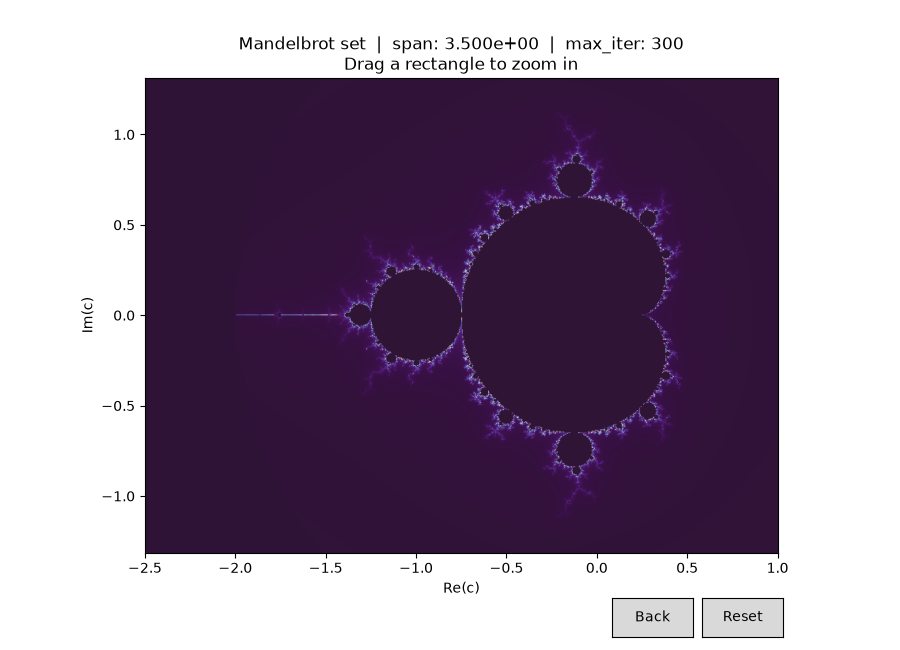

In [1]:
%matplotlib widget
# Interactive Mandelbrot Set explorer, created in part by Claude

import numpy as np
from numba import njit, prange
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector, Button

@njit(parallel=True, fastmath=True, cache=True)
def _mandelbrot_kernel(xmin, xmax, ymin, ymax, width, height, max_iter):
    output = np.zeros((height, width), dtype=np.float64)

    dx = (xmax - xmin) / width
    dy = (ymax - ymin) / height

    for row in prange(height):
        ci = ymin + row * dy
        for col in range(width):
            cr = xmin + col * dx

            zr = 0.0
            zi = 0.0
            it = 0
            zr2 = 0.0
            zi2 = 0.0
            while zr2 + zi2 <= 4.0 and it < max_iter:
                zi = 2.0 * zr * zi + ci
                zr = zr2 - zi2 + cr
                zr2 = zr * zr
                zi2 = zi * zi
                it += 1

            if it == max_iter:
                output[row, col] = max_iter
            else:
                # smooth (continuous) coloring to avoid banding
                log_zn = np.log(zr2 + zi2) / 2.0
                nu = np.log(log_zn / np.log(2.0)) / np.log(2.0)
                smooth_it = it + 1.0 - nu
                output[row, col] = smooth_it

    return output


def compute_mandelbrot(xmin, xmax, ymin, ymax, width, height, max_iter):
    """Wrapper returning an escape-time array of shape (height, width)."""
    return _mandelbrot_kernel(
        float(xmin), float(xmax), float(ymin), float(ymax),
        int(width), int(height), int(max_iter)
    )


class MandelbrotExplorer:
    def __init__(self,
                 width=800, height=600,
                 xmin=-2.5, xmax=1.0, ymin=-1.25, ymax=1.25,
                 max_iter=300, cmap="twilight_shifted"):
        self.width = width
        self.height = height
        self.max_iter = max_iter
        self.cmap = cmap

        # keep aspect ratio consistent with pixel dims on the initial view
        self.default_bounds = self._fit_aspect(xmin, xmax, ymin, ymax)
        self.bounds = self.default_bounds
        self.history = []  # stack of previous bounds, for "Back"

        self.fig = None
        self.ax = None
        self.im = None
        self.selector = None

    def _fit_aspect(self, xmin, xmax, ymin, ymax):
        """Adjust the (x or y) range so it matches width/height aspect ratio."""
        target_ratio = self.width / self.height
        cur_ratio = (xmax - xmin) / (ymax - ymin)
        if cur_ratio > target_ratio:
            # too wide -> expand y
            new_h = (xmax - xmin) / target_ratio
            cy = (ymin + ymax) / 2.0
            ymin, ymax = cy - new_h / 2.0, cy + new_h / 2.0
        else:
            # too tall -> expand x
            new_w = (ymax - ymin) * target_ratio
            cx = (xmin + xmax) / 2.0
            xmin, xmax = cx - new_w / 2.0, cx + new_w / 2.0
        return (xmin, xmax, ymin, ymax)

    def _compute(self):
        xmin, xmax, ymin, ymax = self.bounds
        return compute_mandelbrot(xmin, xmax, ymin, ymax,
                                   self.width, self.height, self.max_iter)

    # plotting section
    def show(self):
        data = self._compute()

        self.fig, self.ax = plt.subplots(figsize=(9, 6.5))
        plt.subplots_adjust(bottom=0.15)

        xmin, xmax, ymin, ymax = self.bounds
        self.im = self.ax.imshow(
            data, extent=(xmin, xmax, ymin, ymax), origin="lower",
            cmap=self.cmap, interpolation="bilinear"
        )
        self.ax.set_xlabel("Re(c)")
        self.ax.set_ylabel("Im(c)")
        self._update_title()

        # Rectangle selection
        self.selector = RectangleSelector(
            self.ax, self._on_select,
            useblit=True,
            button=[1],            # left mouse button only
            minspanx=5, minspany=5,
            spancoords="pixels",
            interactive=False,
        )

        # Buttons
        ax_reset = self.fig.add_axes([0.78, 0.02, 0.09, 0.06])
        ax_back = self.fig.add_axes([0.68, 0.02, 0.09, 0.06])
        self.btn_reset = Button(ax_reset, "Reset")
        self.btn_back = Button(ax_back, "Back")
        self.btn_reset.on_clicked(self._on_reset)
        self.btn_back.on_clicked(self._on_back)

        plt.show()

    def _update_title(self):
        xmin, xmax, ymin, ymax = self.bounds
        width_span = xmax - xmin
        self.ax.set_title(
            f"Mandelbrot set  |  span: {width_span:.3e}  |  "
            f"max_iter: {self.max_iter}\n"
            f"Drag a rectangle to zoom in"
        )

    def _redraw(self):
        data = self._compute()
        xmin, xmax, ymin, ymax = self.bounds
        self.im.set_data(data)
        self.im.set_extent((xmin, xmax, ymin, ymax))
        # rescale color limits to new data range for good contrast
        self.im.set_clim(vmin=data.min(), vmax=data.max())
        self._update_title()
        self.fig.canvas.draw_idle()

    # clikcing
    def _on_select(self, eclick, erelease):
        x0, x1 = sorted([eclick.xdata, erelease.xdata])
        y0, y1 = sorted([eclick.ydata, erelease.ydata])
        if x0 is None or x1 is None or y0 is None or y1 is None:
            return
        if x1 - x0 < 1e-14 or y1 - y0 < 1e-14:
            return  # ignore degenerate selections (e.g. a click, not a drag)

        self.history.append(self.bounds)
        self.bounds = self._fit_aspect(x0, x1, y0, y1)

        # Optionally increase iteration count as we zoom in for more detail
        span = self.bounds[1] - self.bounds[0]
        self.max_iter = int(min(3000, max(300, 300 * np.log10(4.0 / span + 1) + 300)))

        self._redraw()

    def _on_reset(self, event):
        self.history.append(self.bounds)
        self.bounds = self.default_bounds
        self.max_iter = 300
        self._redraw()

    def _on_back(self, event):
        if self.history:
            self.bounds = self.history.pop()
            self._redraw()


if __name__ == "__main__":
    explorer = MandelbrotExplorer()
    explorer.show()

# 1. Python as a calculator

We'll start with using Python in this notebook as a simple calculator

In [1]:
#test your calculations here!


Simple physics problem example. Energy of photon = 1.9 eV.  What's its wavelength? 

$E = hc/\lambda$
so $\lambda = h c / E $.


In [2]:
#your calculations


What if we carry out more sophisticated calculations? Neater way - use variables.

In [3]:
#your calculations


If you copy all these commands into a text file - then that's a .py python script you can run! For now we're going to stick with notebooks.

Make sure to leave comments so that your code is readable.

In [ ]:
#your calculations plus comments


## More on the equal sign

It may seems harmless to write equations like $a=b$ as we are familiar with in maths and physics. However in Python, you'll see the following code produce an error of "NameError: name 'b' is not defined"

In [4]:
#try this
a = 1
a = b

NameError: name 'b' is not defined

In Python (and in almost all programming languages), "=" really means assign. We assign the value on the right to the variable on the left.

In [5]:
#another to show this
a = 4.2
print(a, " before")

a = a + 1.0
print(a, " after")

4.2  before
5.2  after


Comment: this shows that the computer has an internal **state** that keeps track of all variables.

Sometimes we $do$ want to use the equal sign to test if two values are the same. In these cases we use "=="

In [6]:
#your test here

We can even assign the result of evaluating whether $a$ is equal to 2 to another variable!

In [7]:
#your test here